# **Imports & data Loading**

In [ ]:
!pip install nltk
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import numpy as np

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# training data
train_url = 'https://drive.google.com/file/d/1FaHdT2UOnPgT7Enl-EYxrqLM8vwfBKrh/view'
id = train_url.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
train_df = pd.read_csv(new_link)
display(train_df.head())

,News Headline,News Topic
0,<html> <body> News Headlines:\n <br> <b> Presi...,Business
1,<html> <body> News Headlines:\n <br> <b> Will ...,Science and Technology
2,<html> <body> News Headlines:\n <br> <b> Updat...,Business
3,<html> <body> News Headlines:\n <br> <b> Workp...,Business
4,<html> <body> News Headlines:\n <br> <b> Fish ...,Sports


In [ ]:
# testing data
test_url = 'https://drive.google.com/file/d/1I0umPqk98CjfAPUFvX2bQeCFMAAXEwMR/view'
id = test_url.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={id}'
test_df = pd.read_csv(new_link)
display(test_df.head())

,News Headline,News Topic
0,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
1,<html> <body> <br> <br> News Headlines:\n <b>...,Science and Technology
2,<html> <body> <br> <br> News Headlines:\n <b>...,World News
3,<html> <body> <br> <br> News Headlines:\n <b>...,Business
4,<html> <body> <br> <br> News Headlines:\n <b>...,Business


# **Encoding & Splitting Dataset**

In [ ]:
#Label Encoding and split test and train dataset
X_train, y_train = train_df['News Headline'], train_df['News Topic']
X_test, y_test = test_df['News Headline'], test_df['News Topic']

y_train = y_train.map({'Business': 0, 'Science and Technology': 1,'Sports':2, 'World News': 3})
y_test = y_test.map({'Business': 0, 'Science and Technology': 1,'Sports':2, 'World News': 3})

In [ ]:
#Split for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [ ]:
# One-hot encode the labels for the DNN, RNN models
y_train_oh = to_categorical(y_train, num_classes=4)
y_test_oh = to_categorical(y_test, num_classes=4)
y_val_oh = to_categorical(y_val, num_classes=4)

# Tfidf Vectorization

In [ ]:
#Tfidf Vectorization for LR model and DNN
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# **Logistic Regression**

In [ ]:
lr_model = LogisticRegression(
        C=1.0,
        solver='liblinear',
        max_iter=1000,
    )

lr_history = lr_model.fit(X_train_tfidf, y_train)

Accuracy: 0.922569153394803
F1-score (Macro): 0.911377071035404
Validation Classification Report of Logistic Regression Model with No Preprocessing:

              precision    recall  f1-score   support

           0       0.91      0.93      0.92      6093
           1       0.86      0.82      0.84      2662
           2       0.95      0.99      0.97      5446
           3       0.94      0.90      0.92      4887

    accuracy                           0.92     19088
   macro avg       0.92      0.91      0.91     19088
weighted avg       0.92      0.92      0.92     19088

Validation Confusion Matrix of Logistic Regression Model with No Preprocessing:



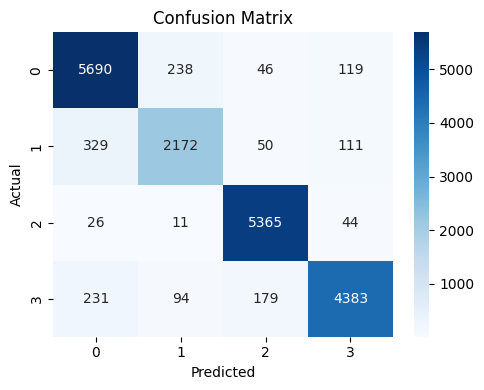

In [ ]:
# validation data evaluation
y_pred = lr_model.predict(X_val_tfidf)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_val, y_pred, average='macro')
print("F1-score (Macro):", f1)

print("Validation Classification Report of Logistic Regression Model with No Preprocessing:\n")
print(classification_report(y_val, y_pred))


print("Validation Confusion Matrix of Logistic Regression Model with No Preprocessing:\n")
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

Accuracy: 0.9021666666666667
F1-score (Macro): 0.9016042184341406
Test Classification Report of Logistic Regression Model with No Preprocessing:

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      3000
           1       0.94      0.80      0.86      3000
           2       0.94      0.98      0.96      3000
           3       0.92      0.90      0.91      3000

    accuracy                           0.90     12000
   macro avg       0.91      0.90      0.90     12000
weighted avg       0.91      0.90      0.90     12000

Test Confusion Matrix of Logistic Regression Model with No Preprocessing:



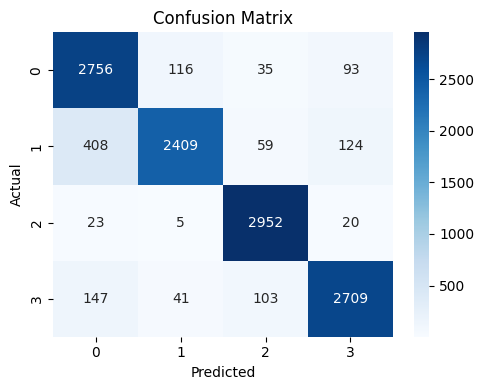

In [ ]:
# test data evaluation
y_pred = lr_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

f1 = f1_score(y_test, y_pred, average='macro')
print("F1-score (Macro):", f1)

print("Test Classification Report of Logistic Regression Model with No Preprocessing:\n")
print(classification_report(y_test, y_pred))


print("Test Confusion Matrix of Logistic Regression Model with No Preprocessing:\n")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Skipgram

In [ ]:
!pip install gensim
import gensim
from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.9 MB/s eta 0:00:00


In [ ]:
# skipgram model training
sentences = [sentence.lower().split() for sentence in X_train]

sg_model = Word2Vec(vector_size=100, window=5, sg=1, min_count=1)

sg_model.build_vocab(sentences)
sg_model.train(sentences, total_examples=len(sentences), epochs=10)

(26204317, 35786150)

In [ ]:
# word to vector conversion
import numpy as np

def sentence_to_vectors(text):
    words = text.lower().split()
    vectors = []

    for word in words:
        if word in sg_model.wv:
            vectors.append(sg_model.wv[word])
        else:
            vectors.append(np.zeros(sg_model.vector_size))
    return np.array(vectors)


X_train_vec = [sentence_to_vectors(s) for s in X_train]
X_val_vec = [sentence_to_vectors(s) for s in X_val]
X_test_vec  = [sentence_to_vectors(s) for s in X_test]

In [ ]:
# padding
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 50

X_train_vec = pad_sequences(X_train_vec, maxlen=max_len, padding='post', dtype='float32')
X_val_vec = pad_sequences(X_val_vec, maxlen=max_len, padding='post', dtype='float32')
X_test_vec  = pad_sequences(X_test_vec, maxlen=max_len, padding='post', dtype='float32')

In [ ]:
X_train_vec.shape

(76352, 50, 100)

# DNN

In [ ]:
dnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_tfidf.shape[1],)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(4, activation="softmax")
])

dnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     6,697,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,708,452 (25.59 MB)

 Trainable params: 6,708,452 (25.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

dnn_history = dnn_model.fit(
    X_train_tfidf, y_train_oh,
    epochs=8,
    batch_size=32,
    validation_data=(X_val_tfidf, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 225s 92ms/step - accuracy: 0.8984 - loss: 0.2989 - val_accuracy: 0.9321 - val_loss: 0.2067
Epoch 2/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 250s 87ms/step - accuracy: 0.9590 - loss: 0.1218 - val_accuracy: 0.9356 - val_loss: 0.2101
Epoch 3/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 232s 97ms/step - accuracy: 0.9779 - loss: 0.0662 - val_accuracy: 0.9357 - val_loss: 0.2465
Epoch 4/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 282s 118ms/step - accuracy: 0.9864 - loss: 0.0395 - val_accuracy: 0.9341 - val_loss: 0.3064


597/597 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step
Validation Accuracy: 0.9321039396479464
Validation F1-score (Macro): 0.9223795617598383
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6093
           1       0.86      0.86      0.86      2662
           2       0.96      0.99      0.97      5446
           3       0.95      0.90      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



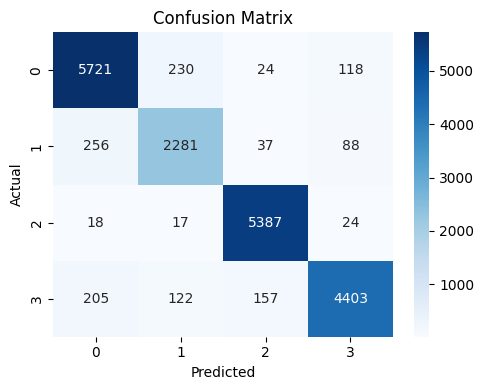

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = dnn_model.predict(X_val_tfidf)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step
Test Accuracy: 0.9163333333333333
Test F1-score (Macro): 0.9159938190203418
Test Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.91      0.89      3000
           1       0.92      0.85      0.89      3000
           2       0.95      0.99      0.97      3000
           3       0.93      0.91      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Test Confusion Matrix:



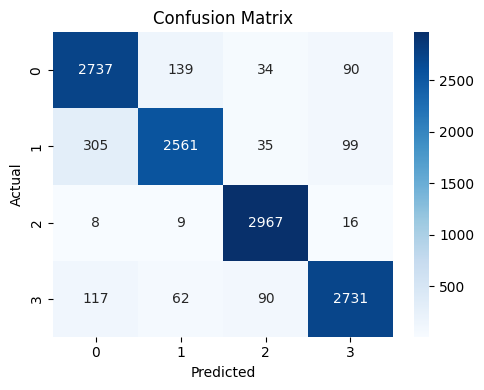

In [ ]:
# Test Data Evaluation
y_test_pred_prob = dnn_model.predict(X_test_tfidf)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# SimpleRNN

In [ ]:
from tensorflow.keras.layers import SimpleRNN

# Get dimensions from your data
max_len = X_train_vec.shape[1]
embedding_dim = X_train_vec.shape[2]

simple_rnn_model = Sequential([
    SimpleRNN(96, input_shape=(max_len, embedding_dim)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

simple_rnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 96)             │        18,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,148 (86.52 KB)

 Trainable params: 22,148 (86.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

simple_rnn_history = simple_rnn_model.fit(
    X_train_vec, y_train_oh,
    epochs=5,
    batch_size=128,
    validation_data = (X_val_vec, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.7406 - loss: 0.6918 - val_accuracy: 0.8462 - val_loss: 0.4905
Epoch 2/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.8511 - loss: 0.4721 - val_accuracy: 0.8710 - val_loss: 0.4249
Epoch 3/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 37s 30ms/step - accuracy: 0.8678 - loss: 0.4348 - val_accuracy: 0.8839 - val_loss: 0.3925
Epoch 4/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.8759 - loss: 0.4097 - val_accuracy: 0.8802 - val_loss: 0.3896
Epoch 5/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.8539 - loss: 0.4681 - val_accuracy: 0.8800 - val_loss: 0.3866


597/597 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Validation Accuracy: 0.8800293378038558
Validation F1-score (Macro): 0.8650644558161429
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      6093
           1       0.72      0.80      0.76      2662
           2       0.94      0.96      0.95      5446
           3       0.90      0.86      0.88      4887

    accuracy                           0.88     19088
   macro avg       0.86      0.87      0.87     19088
weighted avg       0.88      0.88      0.88     19088

Validation Confusion Matrix:



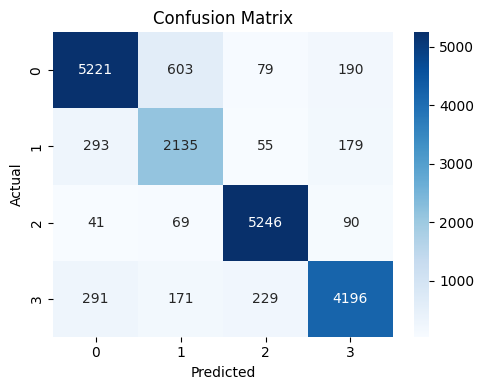

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = simple_rnn_model.predict(X_val_vec)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test Accuracy: 0.8714166666666666
Test F1-score (Macro): 0.8707705741981113
Test Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.85      0.84      3000
           1       0.86      0.80      0.83      3000
           2       0.92      0.97      0.95      3000
           3       0.88      0.86      0.87      3000

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000

Test Confusion Matrix:



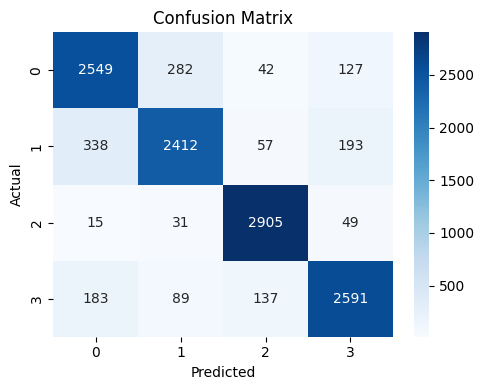

In [ ]:
# Test Data Evaluation
y_test_pred_prob = simple_rnn_model.predict(X_test_vec)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# LSTM

In [ ]:
from tensorflow.keras.layers import LSTM

max_len = X_train_vec.shape[1]
embedding_dim = X_train_vec.shape[2]

lstm_model = Sequential([
    LSTM(128, input_shape=(max_len, embedding_dim)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,276 (524.52 KB)

 Trainable params: 134,276 (524.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_lstm = lstm_model.fit(
    X_train_vec, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_vec, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 163s 67ms/step - accuracy: 0.8819 - loss: 0.3568 - val_accuracy: 0.9039 - val_loss: 0.2904
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 161s 68ms/step - accuracy: 0.9069 - loss: 0.2741 - val_accuracy: 0.9096 - val_loss: 0.2673
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 214s 73ms/step - accuracy: 0.9138 - loss: 0.2512 - val_accuracy: 0.9159 - val_loss: 0.2449
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 201s 72ms/step - accuracy: 0.9202 - loss: 0.2291 - val_accuracy: 0.9166 - val_loss: 0.2409
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 160s 67ms/step - accuracy: 0.9257 - loss: 0.2102 - val_accuracy: 0.9191 - val_loss: 0.2277
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 171s 72ms/step - accuracy: 0.9307 - loss: 0.1935 - val_accuracy: 0.9218 - val_loss: 0.2250
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 187s 78ms/step - accuracy: 0.9374 - loss: 0.1767 - val_accuracy: 0.9270 - val_loss: 0.2155
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 196s 76ms/step - accuracy: 

597/597 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step
Validation Accuracy: 0.9314752724224644
Validation F1-score (Macro): 0.9207434141330626
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      6093
           1       0.83      0.86      0.85      2662
           2       0.98      0.98      0.98      5446
           3       0.94      0.92      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



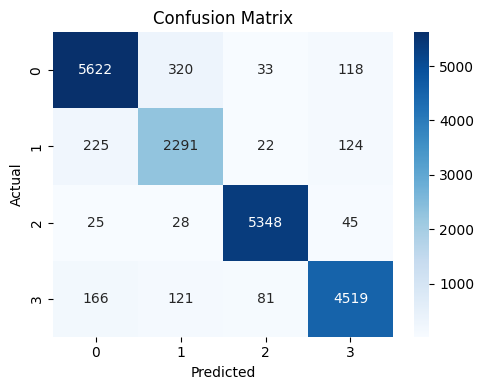

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = lstm_model.predict(X_val_vec)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step
Test Accuracy: 0.9175
Test F1-score (Macro): 0.9172201128108821
Test Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      3000
           1       0.91      0.86      0.88      3000
           2       0.97      0.98      0.97      3000
           3       0.91      0.93      0.92      3000

    accuracy                           0.92     12000
   macro avg       0.92      0.92      0.92     12000
weighted avg       0.92      0.92      0.92     12000

Test Confusion Matrix:



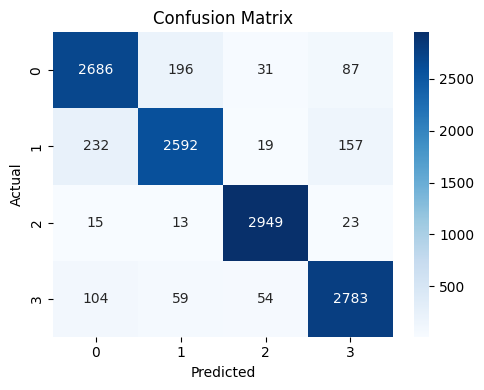

In [ ]:
# Test Data Evaluation
y_test_pred_prob = lstm_model.predict(X_test_vec)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# GRU

In [ ]:
from tensorflow.keras.layers import GRU

max_len = X_train_vec.shape[1]
embedding_dim = X_train_vec.shape[2]

gru_model = Sequential([
    GRU(96, input_shape=(max_len, embedding_dim)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 96)             │        57,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,956 (273.27 KB)

 Trainable params: 69,956 (273.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_gru = gru_model.fit(
    X_train_vec, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_vec, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 98s 39ms/step - accuracy: 0.8738 - loss: 0.3485 - val_accuracy: 0.9084 - val_loss: 0.2724
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 95s 40ms/step - accuracy: 0.9113 - loss: 0.2558 - val_accuracy: 0.9137 - val_loss: 0.2552
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 92s 38ms/step - accuracy: 0.9186 - loss: 0.2328 - val_accuracy: 0.9193 - val_loss: 0.2307
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 143s 39ms/step - accuracy: 0.9246 - loss: 0.2108 - val_accuracy: 0.9235 - val_loss: 0.2194
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 92s 39ms/step - accuracy: 0.9309 - loss: 0.1920 - val_accuracy: 0.9262 - val_loss: 0.2172
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 92s 39ms/step - accuracy: 0.9380 - loss: 0.1742 - val_accuracy: 0.9278 - val_loss: 0.2120
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 94s 39ms/step - accuracy: 0.9449 - loss: 0.1567 - val_accuracy: 0.9319 - val_loss: 0.2084
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 143s 40ms/step - accuracy: 0.9498

597/597 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step
Validation Accuracy: 0.931894383906119
Validation F1-score (Macro): 0.9213332661890382
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.93      0.93      6093
           1       0.86      0.84      0.85      2662
           2       0.97      0.98      0.98      5446
           3       0.94      0.93      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



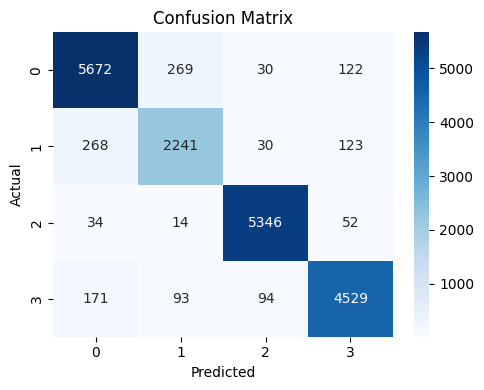

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = gru_model.predict(X_val_vec)

y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step
Test Accuracy: 0.9094166666666667
Test F1-score (Macro): 0.9090744530166472
Test Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      3000
           1       0.91      0.84      0.87      3000
           2       0.96      0.98      0.97      3000
           3       0.91      0.92      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix:



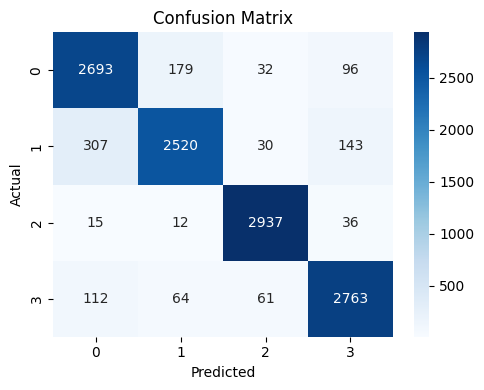

In [ ]:
# Test Data Evaluation
y_test_pred_prob = gru_model.predict(X_test_vec)

y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional SimpleRNN

In [ ]:
from tensorflow.keras.layers import Bidirectional, SimpleRNN, Input

max_len = X_train_vec.shape[1]
embedding_dim = X_train_vec.shape[2]

bidirectional_simple_rnn_model = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(SimpleRNN(96, input_shape=(max_len, embedding_dim))),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_simple_rnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

bidirectional_simple_rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 192)            │        37,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,132 (172.39 KB)

 Trainable params: 44,132 (172.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_simple_rnn = bidirectional_simple_rnn_model.fit(
    X_train_vec, y_train_oh,
    epochs=5,
    batch_size=128,
    validation_data=(X_val_vec, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 41s 57ms/step - accuracy: 0.8168 - loss: 0.5080 - val_accuracy: 0.8887 - val_loss: 0.3375
Epoch 2/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.8853 - loss: 0.3506 - val_accuracy: 0.8844 - val_loss: 0.3395
Epoch 3/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.8903 - loss: 0.3339 - val_accuracy: 0.8948 - val_loss: 0.3185
Epoch 4/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.8942 - loss: 0.3158 - val_accuracy: 0.8951 - val_loss: 0.3175
Epoch 5/5
597/597 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.8965 - loss: 0.3074 - val_accuracy: 0.8915 - val_loss: 0.3181


597/597 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step
Validation Accuracy: 0.8951173512154234
Validation F1-score (Macro): 0.8806031672918263
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.89      0.89      6093
           1       0.79      0.77      0.78      2662
           2       0.96      0.95      0.96      5446
           3       0.89      0.90      0.89      4887

    accuracy                           0.90     19088
   macro avg       0.88      0.88      0.88     19088
weighted avg       0.89      0.90      0.89     19088

Validation Confusion Matrix:



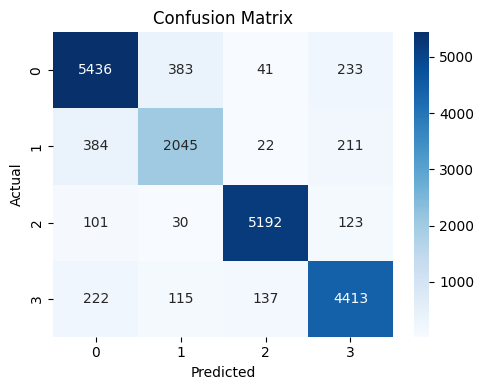

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_simple_rnn_model.predict(X_val_vec)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Test Accuracy: 0.8765
Test F1-score (Macro): 0.8760035367538787
Test Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.90      0.84      3000
           1       0.89      0.76      0.82      3000
           2       0.96      0.95      0.96      3000
           3       0.87      0.90      0.88      3000

    accuracy                           0.88     12000
   macro avg       0.88      0.88      0.88     12000
weighted avg       0.88      0.88      0.88     12000

Test Confusion Matrix:



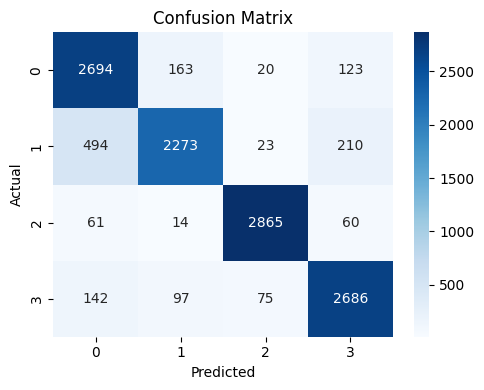

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_simple_rnn_model.predict(X_test_vec)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional LSTM

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional, Input

max_len = X_train_vec.shape[1]
embedding_dim = X_train_vec.shape[2]

bidirectional_lstm_model = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(LSTM(128)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bidirectional_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,908 (1.02 MB)

 Trainable params: 267,908 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_lstm = bidirectional_lstm_model.fit(
    X_train_vec, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_data= (X_val_vec, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 329s 135ms/step - accuracy: 0.8873 - loss: 0.3260 - val_accuracy: 0.9050 - val_loss: 0.2682
Epoch 2/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 323s 135ms/step - accuracy: 0.9107 - loss: 0.2556 - val_accuracy: 0.9096 - val_loss: 0.2582
Epoch 3/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 377s 133ms/step - accuracy: 0.9187 - loss: 0.2290 - val_accuracy: 0.9103 - val_loss: 0.2532
Epoch 4/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 320s 134ms/step - accuracy: 0.9268 - loss: 0.2062 - val_accuracy: 0.9234 - val_loss: 0.2195
Epoch 5/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 332s 139ms/step - accuracy: 0.9349 - loss: 0.1829 - val_accuracy: 0.9290 - val_loss: 0.2092
Epoch 6/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 371s 134ms/step - accuracy: 0.9419 - loss: 0.1632 - val_accuracy: 0.9316 - val_loss: 0.2046
Epoch 7/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 321s 135ms/step - accuracy: 0.9496 - loss: 0.1436 - val_accuracy: 0.9288 - val_loss: 0.2130
Epoch 8/10
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 327s 137ms/step - ac

597/597 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step
Validation Accuracy: 0.9316324392288349
Validation F1-score (Macro): 0.9213242068021436
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6093
           1       0.83      0.87      0.85      2662
           2       0.97      0.99      0.98      5446
           3       0.94      0.92      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



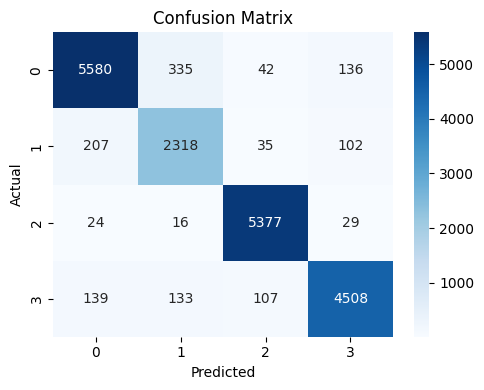

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_lstm_model.predict(X_val_vec)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step
Test Accuracy: 0.9131666666666667
Test F1-score (Macro): 0.9127206838644218
Test Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88      3000
           1       0.90      0.87      0.88      3000
           2       0.95      0.99      0.97      3000
           3       0.92      0.92      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix:



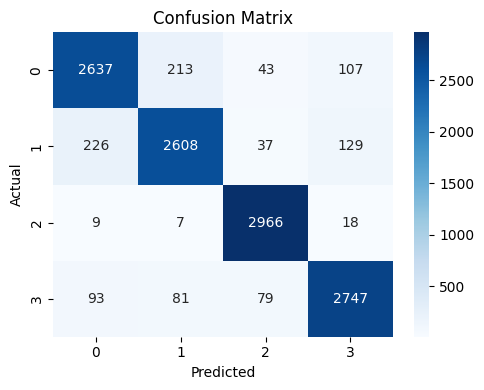

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_lstm_model.predict(X_test_vec)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

# Bidirectional GRU

In [ ]:
from tensorflow.keras.layers import GRU, Bidirectional, Input

max_len = X_train_vec.shape[1]
embedding_dim = X_train_vec.shape[2]

bidirectional_gru_model = Sequential([
    Input(shape=(max_len, embedding_dim)), # Explicit Input layer
    Bidirectional(GRU(128)),
    Dropout(0.25),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

bidirectional_gru_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

bidirectional_gru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,348 (755.27 KB)

 Trainable params: 193,348 (755.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

history_bidirectional_gru = bidirectional_gru_model.fit(
    X_train_vec, y_train_oh,
    epochs=8,
    batch_size=32,
    validation_data = (X_val_vec, y_val_oh),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 250s 103ms/step - accuracy: 0.8760 - loss: 0.3449 - val_accuracy: 0.8999 - val_loss: 0.2990
Epoch 2/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 244s 102ms/step - accuracy: 0.9094 - loss: 0.2618 - val_accuracy: 0.9102 - val_loss: 0.2595
Epoch 3/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 267s 104ms/step - accuracy: 0.9151 - loss: 0.2397 - val_accuracy: 0.9151 - val_loss: 0.2430
Epoch 4/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 258s 103ms/step - accuracy: 0.9199 - loss: 0.2216 - val_accuracy: 0.9188 - val_loss: 0.2278
Epoch 5/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 258s 101ms/step - accuracy: 0.9279 - loss: 0.2013 - val_accuracy: 0.9259 - val_loss: 0.2134
Epoch 6/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 268s 103ms/step - accuracy: 0.9337 - loss: 0.1843 - val_accuracy: 0.9278 - val_loss: 0.2056
Epoch 7/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 251s 105ms/step - accuracy: 0.9403 - loss: 0.1673 - val_accuracy: 0.9197 - val_loss: 0.2247
Epoch 8/8
2386/2386 ━━━━━━━━━━━━━━━━━━━━ 255s 102ms/step - accuracy: 

597/597 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step
Validation Accuracy: 0.9278080469404861
Validation F1-score (Macro): 0.9165718414278065
Validation Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      6093
           1       0.84      0.84      0.84      2662
           2       0.97      0.98      0.98      5446
           3       0.93      0.92      0.93      4887

    accuracy                           0.93     19088
   macro avg       0.92      0.92      0.92     19088
weighted avg       0.93      0.93      0.93     19088

Validation Confusion Matrix:



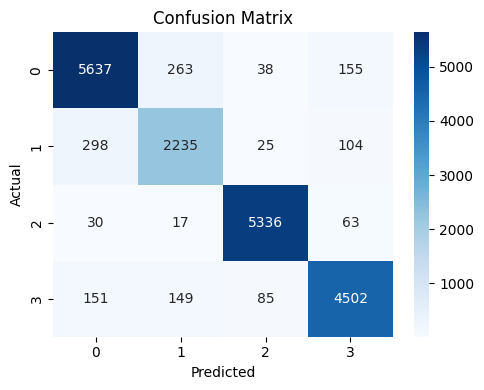

In [ ]:
# Validation Data Evaluation
y_val_pred_prob = bidirectional_gru_model.predict(X_val_vec)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_val_oh, axis=1)

accuracy = accuracy_score(y_val_true, y_val_pred)
print("Validation Accuracy:", accuracy)

f1 = f1_score(y_val_true, y_val_pred, average='macro')
print("Validation F1-score (Macro):", f1)

print("Validation Classification Report:\n")
print(classification_report(y_val_true, y_val_pred))

print("Validation Confusion Matrix:\n")
cm = confusion_matrix(y_val_true, y_val_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step
Test Accuracy: 0.9141666666666667
Test F1-score (Macro): 0.9138957771187974
Test Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      3000
           1       0.91      0.85      0.88      3000
           2       0.97      0.98      0.97      3000
           3       0.92      0.92      0.92      3000

    accuracy                           0.91     12000
   macro avg       0.91      0.91      0.91     12000
weighted avg       0.91      0.91      0.91     12000

Test Confusion Matrix:



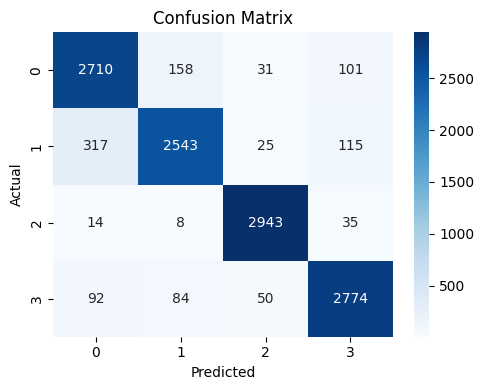

In [ ]:
# Test Data Evaluation
y_test_pred_prob = bidirectional_gru_model.predict(X_test_vec)
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

y_test_true = np.argmax(y_test_oh, axis=1)

accuracy = accuracy_score(y_test_true, y_test_pred)
print("Test Accuracy:", accuracy)

f1 = f1_score(y_test_true, y_test_pred, average='macro')
print("Test F1-score (Macro):", f1)

print("Test Classification Report:\n")
print(classification_report(y_test_true, y_test_pred))


print("Test Confusion Matrix:\n")
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()